# Week 9 Challenge

## Task 1: Data Preprocessing and Exploratory Data Analysis

Author: Lalise Fufi

Date: July 2026

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.stattools import adfuller

plt.style.use("ggplot")

%matplotlib inline

2. Download Data

In [2]:
# ==========================================================
# Download Historical Data
# ==========================================================

start_date = "2015-01-01"
end_date = "2026-06-30"

tsla = yf.download("TSLA", start=start_date, end=end_date)

bnd = yf.download("BND", start=start_date, end=end_date)

spy = yf.download("SPY", start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


3. View Data

In [3]:
tsla.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


In [4]:
bnd.head()

Price,Close,High,Low,Open,Volume
Ticker,BND,BND,BND,BND,BND
Date,,,,,
2015-01-02,59.205658,59.234312,59.040897,59.048062,2218800
2015-01-05,59.377544,59.399034,59.241438,59.270092,5820100
2015-01-06,59.549492,59.728577,59.477859,59.477859,3887600
2015-01-07,59.585327,59.656960,59.492205,59.556673,2433400
2015-01-08,59.492218,59.535197,59.434909,59.535197,1873400


In [5]:
spy.head()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2015-01-02,169.687866,170.885595,168.655350,170.472589,121465900
2015-01-05,166.623322,168.812251,166.317701,168.647051,169632600
2015-01-06,165.053925,167.449357,164.260947,166.928965,209151400
2015-01-07,167.110687,167.449356,165.929495,166.375536,125346700
2015-01-08,170.076141,170.290913,168.498465,168.514977,147217800


4. Save Raw Data

In [6]:
tsla.to_csv("../data/raw/TSLA.csv")
bnd.to_csv("../data/raw/BND.csv")
spy.to_csv("../data/raw/SPY.csv")

5. Data Information

In [7]:
tsla.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   2888 non-null   float64
 1   (High, TSLA)    2888 non-null   float64
 2   (Low, TSLA)     2888 non-null   float64
 3   (Open, TSLA)    2888 non-null   float64
 4   (Volume, TSLA)  2888 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.4 KB


In [8]:
bnd.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, BND)   2888 non-null   float64
 1   (High, BND)    2888 non-null   float64
 2   (Low, BND)     2888 non-null   float64
 3   (Open, BND)    2888 non-null   float64
 4   (Volume, BND)  2888 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.4 KB


In [9]:
spy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   2888 non-null   float64
 1   (High, SPY)    2888 non-null   float64
 2   (Low, SPY)     2888 non-null   float64
 3   (Open, SPY)    2888 non-null   float64
 4   (Volume, SPY)  2888 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.4 KB


6. Summary Statistics

In [10]:
tsla.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,148.773923,151.990563,145.416731,148.797341,1.087922e+08
std,138.895957,141.852818,135.867193,138.977191,7.082549e+07
min,9.578000,10.331333,9.403333,9.488000,1.062000e+07
25%,18.393499,18.665168,18.023666,18.390833,6.548325e+07
50%,133.437668,136.053329,125.831669,131.496330,9.033615e+07
75%,251.925831,257.485008,245.832500,251.680004,1.261204e+08
max,489.880005,498.829987,485.329987,489.880005,9.140820e+08


In [11]:
bnd.describe()

Price,Close,High,Low,Open,Volume
Ticker,BND,BND,BND,BND,BND
count,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,66.281145,66.377917,66.182484,66.283382,4.653786e+06
std,4.700144,4.706374,4.692193,4.699780,3.017704e+06
min,58.531723,58.604103,58.495542,58.560671,0.000000e+00
25%,62.267993,62.326403,62.195300,62.262819,2.233700e+06
50%,65.507401,65.631343,65.376217,65.491547,4.280650e+06
75%,70.451469,70.604823,70.312554,70.451208,6.246475e+06
max,74.581291,74.672974,74.547951,74.639639,3.396300e+07


In [12]:
spy.describe()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
count,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,351.505532,353.335695,349.374635,351.441777,8.551049e+07
std,155.443935,156.153561,154.576728,155.414686,4.338553e+07
min,154.161575,155.206972,152.073435,153.723182,2.027000e+07
25%,223.546833,224.825560,222.172455,223.474575,5.836455e+07
50%,312.817917,315.491361,310.494730,314.142246,7.541950e+07
75%,432.806847,434.994719,430.305388,432.604503,9.882245e+07
max,757.618225,758.446109,754.805464,756.201867,5.072443e+08


7. Missing Values

In [13]:
tsla.isnull().sum()

Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64

In [14]:
bnd.isnull().sum()

Price   Ticker
Close   BND       0
High    BND       0
Low     BND       0
Open    BND       0
Volume  BND       0
dtype: int64

In [15]:
spy.isnull().sum()

Price   Ticker
Close   SPY       0
High    SPY       0
Low     SPY       0
Open    SPY       0
Volume  SPY       0
dtype: int64

8. Handle Missing Values

In [16]:
tsla = tsla.ffill().bfill()

bnd = bnd.ffill().bfill()

spy = spy.ffill().bfill()

9. Data Types

In [17]:
tsla.dtypes

Price   Ticker
Close   TSLA      float64
High    TSLA      float64
Low     TSLA      float64
Open    TSLA      float64
Volume  TSLA        int64
dtype: object

In [18]:
bnd.dtypes

Price   Ticker
Close   BND       float64
High    BND       float64
Low     BND       float64
Open    BND       float64
Volume  BND         int64
dtype: object

In [19]:
spy.dtypes

Price   Ticker
Close   SPY       float64
High    SPY       float64
Low     SPY       float64
Open    SPY       float64
Volume  SPY         int64
dtype: object

10. Normalize Closing Prices

In [20]:
scaler = MinMaxScaler()

tsla["Scaled Close"] = scaler.fit_transform(tsla[["Close"]])

bnd["Scaled Close"] = scaler.fit_transform(bnd[["Close"]])

spy["Scaled Close"] = scaler.fit_transform(spy[["Close"]])

11. Plot Closing Prices

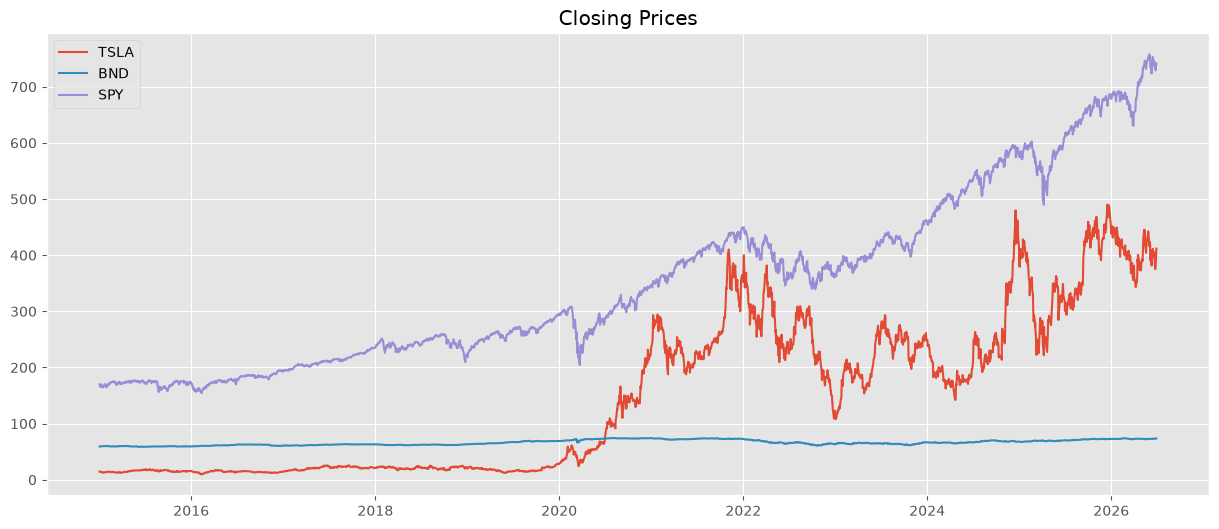

In [21]:
plt.figure(figsize=(15,6))

plt.plot(tsla.index, tsla["Close"], label="TSLA")
plt.plot(bnd.index, bnd["Close"], label="BND")
plt.plot(spy.index, spy["Close"], label="SPY")

plt.title("Closing Prices")

plt.legend()

plt.show()

## Interpretation of Closing Price Trends

### Key Observations

The chart shows the historical closing prices of **Tesla (TSLA)**, **Vanguard Total Bond Market ETF (BND)**, and the **SPDR S&P 500 ETF (SPY)** from **January 2015 to June 2026**.

- **Tesla (TSLA)** experienced the highest price volatility among the three assets. Its stock price remained relatively low until 2020, after which it increased rapidly with several sharp rises and declines. This behavior reflects Tesla's high-risk, high-return nature and indicates that investors experienced significant price fluctuations over the study period.

- **BND** maintained a relatively stable price throughout the entire period. Compared to TSLA and SPY, BND showed only small price movements, making it the least volatile asset. This stability is expected because BND is a bond ETF designed to provide steady income with lower investment risk.

- **SPY** displayed a consistent long-term upward trend despite temporary declines during periods of market uncertainty. Although its price fluctuated over time, the movements were much smoother than Tesla's, demonstrating moderate risk and long-term market growth.

### Business Insight

From a portfolio management perspective:

- **TSLA** offers the greatest potential for capital appreciation but also carries substantial investment risk due to its high volatility.
- **BND** acts as a defensive asset that helps reduce overall portfolio risk.
- **SPY** provides diversified exposure to the U.S. stock market and delivers a balance between growth and stability.

These observations suggest that combining all three assets can improve portfolio diversification by balancing expected returns with investment risk.

12. Daily Returns

In [22]:
tsla["Daily Return"] = tsla["Close"].pct_change()

bnd["Daily Return"] = bnd["Close"].pct_change()

spy["Daily Return"] = spy["Close"].pct_change()

13. Plot Daily Returns

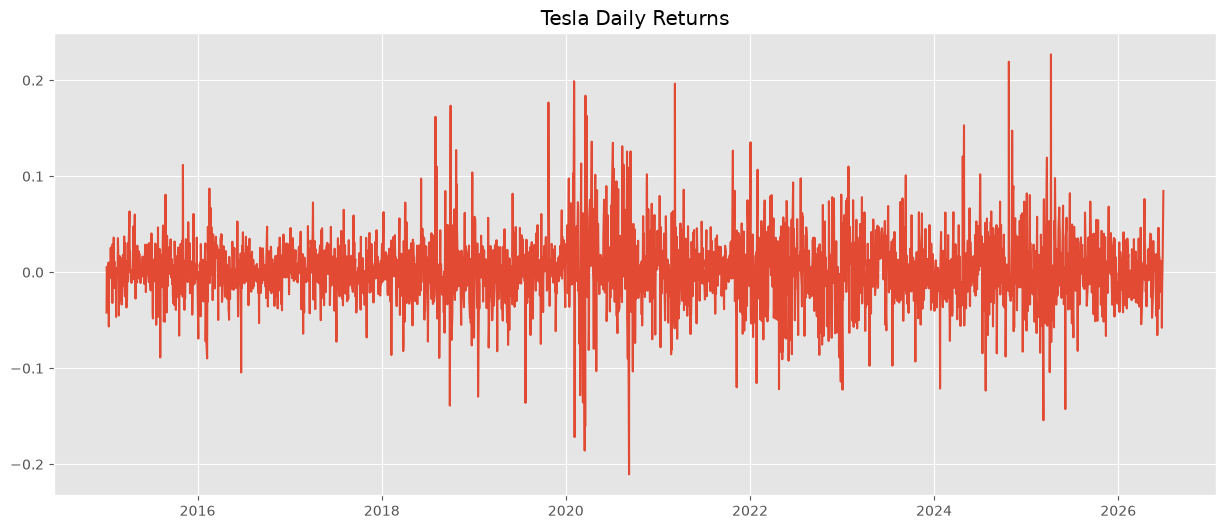

In [23]:
plt.figure(figsize=(15,6))

plt.plot(tsla.index, tsla["Daily Return"])

plt.title("Tesla Daily Returns")

plt.show()

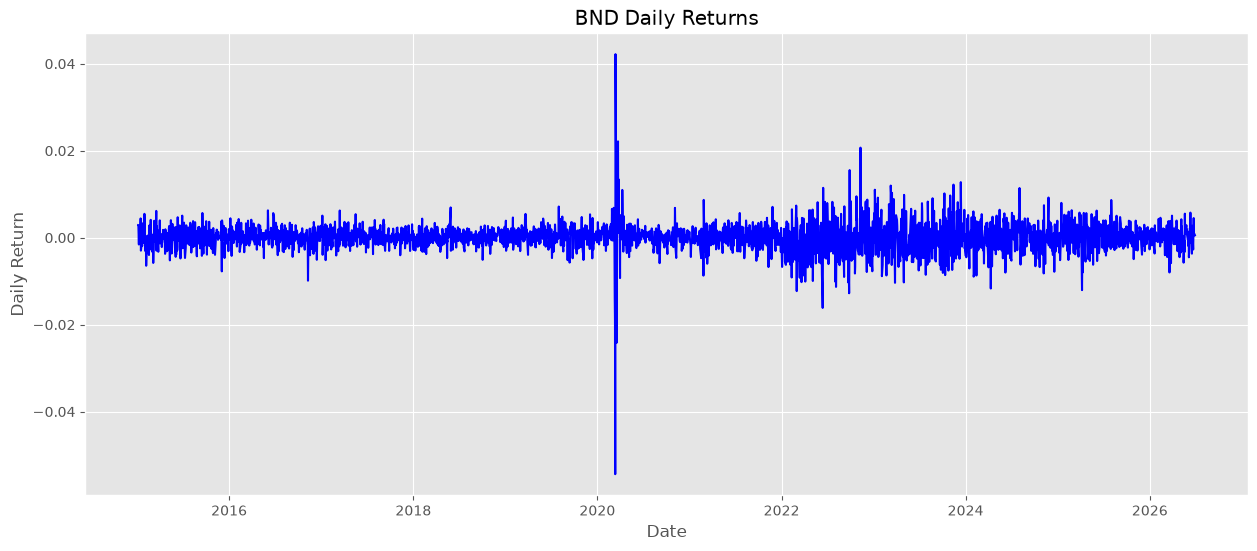

In [24]:
plt.figure(figsize=(15,6))

plt.plot(bnd.index, bnd["Daily Return"], color="blue")

plt.title("BND Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

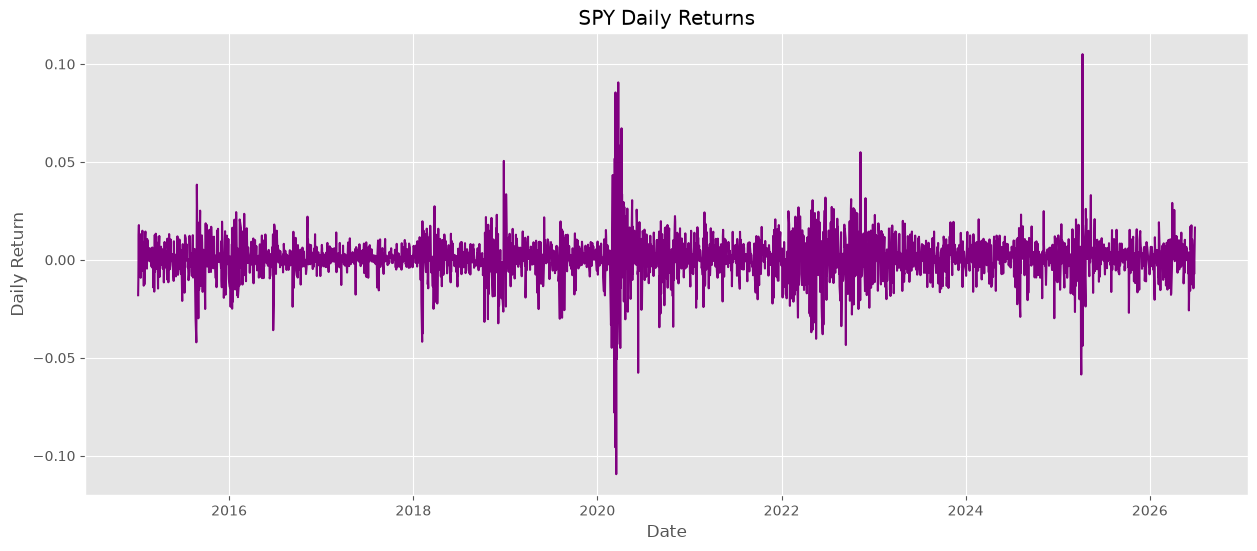

In [25]:
plt.figure(figsize=(15,6))

plt.plot(spy.index, spy["Daily Return"], color="purple")

plt.title("SPY Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

# Interpretation of Daily Returns (TSLA, BND, and SPY)

The daily return plots illustrate the day-to-day percentage changes in the prices of Tesla (TSLA), Vanguard Total Bond Market ETF (BND), and the SPDR S&P 500 ETF (SPY) from **January 2015 to June 2026**. All three return series fluctuate around zero, indicating that daily gains and losses are distributed around an average close to zero, which is typical for financial return data.

### Tesla (TSLA)

Tesla exhibits the highest level of volatility among the three assets. The daily returns contain numerous large positive and negative spikes, particularly during **2020–2021** and **2024–2025**, indicating periods of significant market uncertainty and rapid price changes. These large fluctuations highlight Tesla's high-risk, high-return characteristics. Although investors have opportunities for substantial gains, they are also exposed to considerable downside risk.

### Vanguard Total Bond Market ETF (BND)

BND shows the lowest volatility throughout the observation period. Most daily returns remain very close to zero, with only a few isolated spikes, most notably around **early 2020** during the COVID-19 market disruption. Compared with TSLA and SPY, BND demonstrates much greater price stability, confirming its role as a low-risk investment that provides stability and helps reduce overall portfolio risk.

### SPDR S&P 500 ETF (SPY)

SPY displays moderate volatility, with daily returns fluctuating around zero but remaining less extreme than Tesla's. Increased volatility is visible during major market events, particularly around **2020**, after which the return series returns to more moderate fluctuations. As a diversified ETF tracking the S&P 500 Index, SPY provides a balance between growth and stability, making it suitable for long-term investment and portfolio diversification.

## Comparative Analysis

Comparing the three assets reveals clear differences in their risk profiles:

- **TSLA** has the highest volatility, indicating the greatest investment risk but also the highest potential return.
- **BND** has the lowest volatility, making it the most stable asset and an effective tool for reducing portfolio risk.
- **SPY** falls between TSLA and BND, offering moderate volatility and diversified exposure to the overall U.S. stock market.

These findings support the principles of portfolio diversification. Combining TSLA's growth potential with BND's stability and SPY's diversified market exposure can help investors achieve a better balance between expected returns and investment risk.

## Implication for Time Series Modeling

The absence of a persistent upward or downward trend in the daily return series suggests that the returns are more likely to be **stationary** than the original closing prices. This makes daily returns more suitable for statistical forecasting models such as **ARIMA**, subject to confirmation through the Augmented Dickey-Fuller (ADF) stationarity test.

14. Rolling Mean

In [26]:
tsla["Rolling Mean"] = tsla["Close"].rolling(30).mean()

In [27]:
#Rolling Std
tsla["Rolling Std"] = tsla["Close"].rolling(30).std()

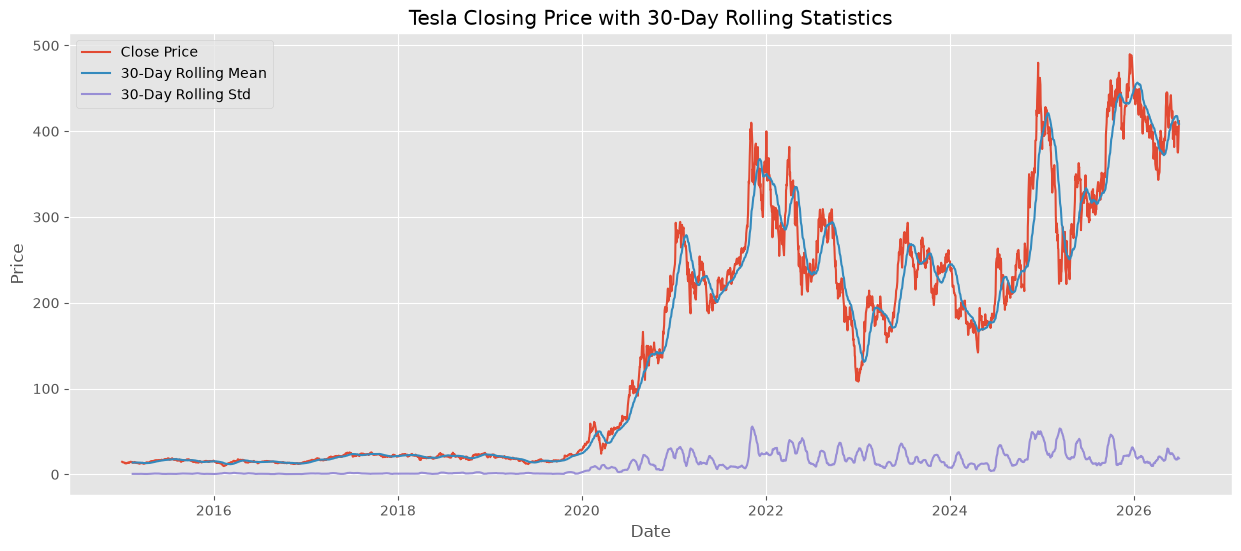

In [28]:
plt.figure(figsize=(15,6))

plt.plot(tsla["Close"], label="Close Price")
plt.plot(tsla["Rolling Mean"], label="30-Day Rolling Mean")
plt.plot(tsla["Rolling Std"], label="30-Day Rolling Std")

plt.title("Tesla Closing Price with 30-Day Rolling Statistics")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

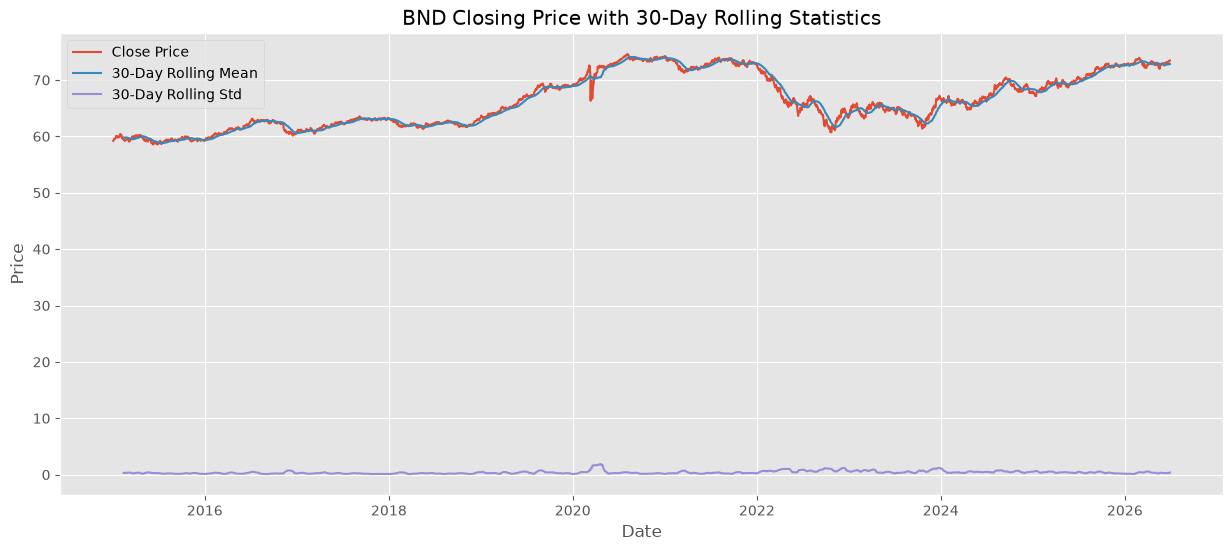

In [29]:
bnd["Rolling Mean"] = bnd["Close"].rolling(window=30).mean()
bnd["Rolling Std"] = bnd["Close"].rolling(window=30).std()

plt.figure(figsize=(15,6))

plt.plot(bnd["Close"], label="Close Price")
plt.plot(bnd["Rolling Mean"], label="30-Day Rolling Mean")
plt.plot(bnd["Rolling Std"], label="30-Day Rolling Std")

plt.title("BND Closing Price with 30-Day Rolling Statistics")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

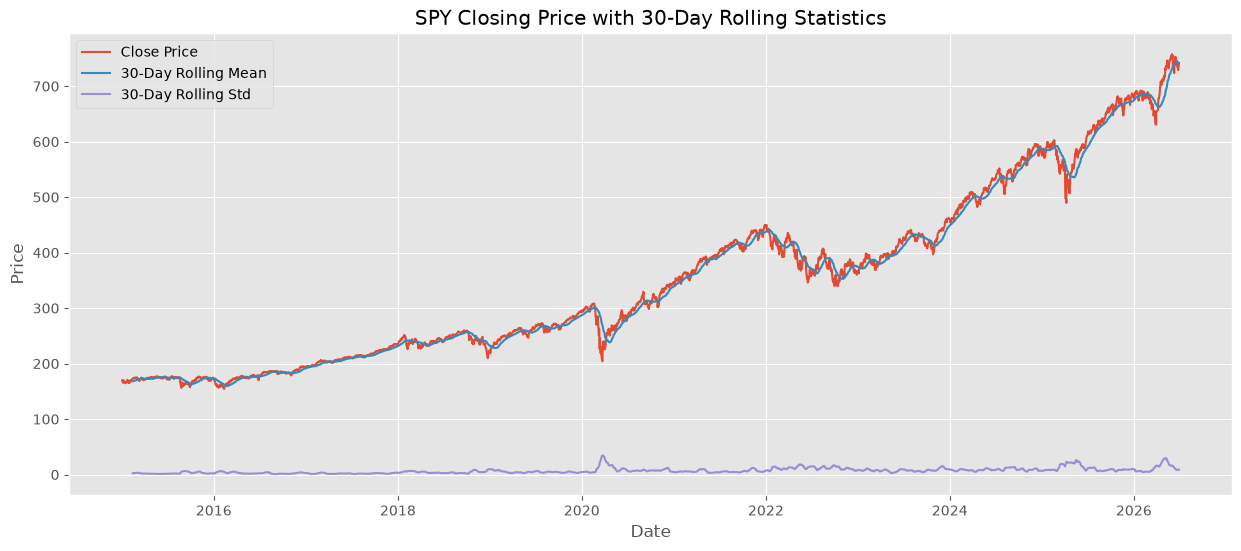

In [30]:
spy["Rolling Mean"] = spy["Close"].rolling(window=30).mean()
spy["Rolling Std"] = spy["Close"].rolling(window=30).std()

plt.figure(figsize=(15,6))

plt.plot(spy["Close"], label="Close Price")
plt.plot(spy["Rolling Mean"], label="30-Day Rolling Mean")
plt.plot(spy["Rolling Std"], label="30-Day Rolling Std")

plt.title("SPY Closing Price with 30-Day Rolling Statistics")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

# Interpretation of 30-Day Rolling Mean and Rolling Standard Deviation

The following plots present the **closing price**, **30-day rolling mean**, and **30-day rolling standard deviation** for TSLA, BND, and SPY. The rolling mean smooths short-term price fluctuations to reveal the underlying trend, while the rolling standard deviation measures the level of price volatility over time.

### Tesla (TSLA)

Tesla shows the highest volatility among the three assets. The closing price increases dramatically after 2020 but experiences several sharp rises and declines. The 30-day rolling mean closely follows the long-term trend while smoothing short-term fluctuations. The rolling standard deviation increases substantially during periods of rapid price movements, especially between 2020 and 2025, indicating a high level of investment risk. These results confirm that Tesla is a high-growth but highly volatile asset.

### Vanguard Total Bond Market ETF (BND)

BND exhibits relatively stable price movements throughout the study period. The closing price and the 30-day rolling mean remain closely aligned, indicating a consistent long-term trend with only minor fluctuations. The rolling standard deviation stays at a very low level for most of the period, with a temporary increase around early 2020 during the COVID-19 market disruption. This confirms that BND is the least volatile asset and serves as a stable, defensive investment.

### SPDR S&P 500 ETF (SPY)

SPY demonstrates a steady upward trend over the entire period. The 30-day rolling mean follows the closing price closely, indicating sustained long-term market growth. The rolling standard deviation increases during periods of market uncertainty, particularly around 2020 and during subsequent market corrections, but remains significantly lower than Tesla's. This suggests that SPY provides moderate volatility while maintaining consistent long-term growth.

## Comparative Analysis

Comparing the three assets reveals clear differences in both trend and volatility:

- **Tesla (TSLA)** has the highest rolling standard deviation, indicating the greatest price volatility and investment risk, but also the highest growth potential.
- **BND** has the lowest rolling standard deviation and the smoothest price trend, making it the most stable asset in the portfolio.
- **SPY** exhibits moderate volatility with a strong long-term upward trend, offering a balance between growth and stability.

Overall, the rolling statistics demonstrate that **TSLA is suitable for investors seeking higher returns despite greater risk, BND provides stability and capital preservation, and SPY offers diversified long-term market growth**. Combining these three assets in a portfolio can improve diversification by balancing risk and expected return.

15. Outlier Detection

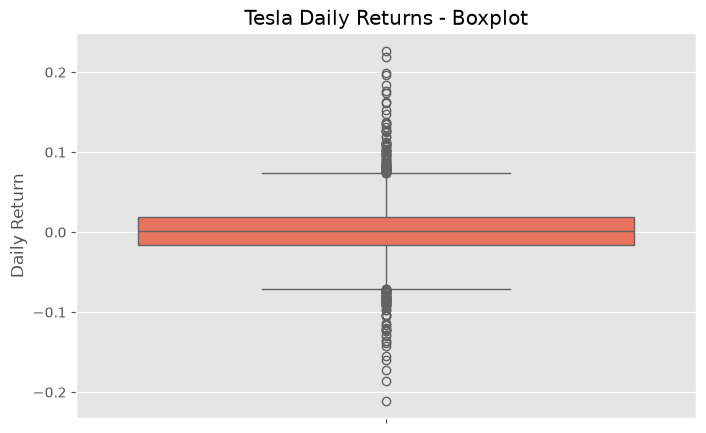

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(y=tsla["Daily Return"], color="tomato")

plt.title("Tesla Daily Returns - Boxplot")
plt.ylabel("Daily Return")

plt.show()

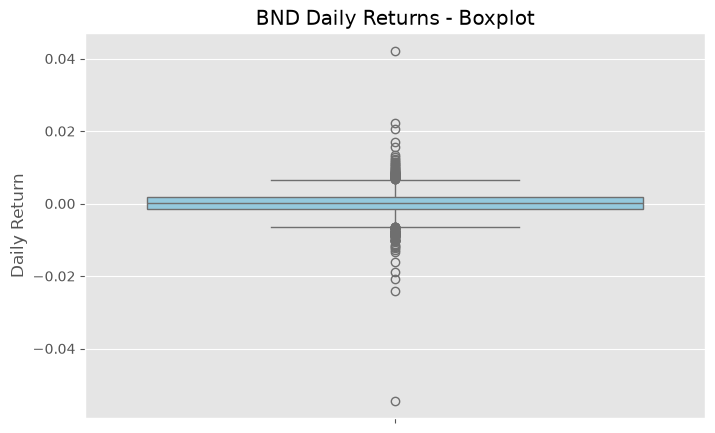

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(y=bnd["Daily Return"], color="skyblue")

plt.title("BND Daily Returns - Boxplot")
plt.ylabel("Daily Return")

plt.show()

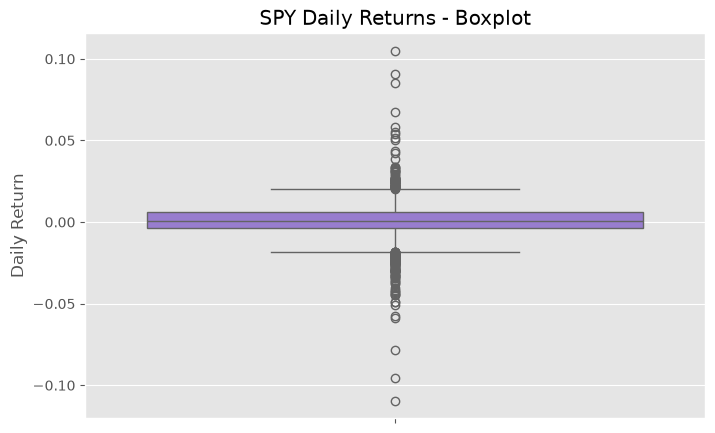

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(y=spy["Daily Return"], color="mediumpurple")

plt.title("SPY Daily Returns - Boxplot")
plt.ylabel("Daily Return")

plt.show()

# Interpretation of Boxplots for Daily Returns

The boxplots summarize the distribution of daily returns for **Tesla (TSLA)**, **Vanguard Total Bond Market ETF (BND)**, and the **SPDR S&P 500 ETF (SPY)**. They provide insight into the central tendency, variability, and presence of extreme daily returns (outliers), which are important indicators of investment risk.

### Tesla (TSLA)

Tesla exhibits the widest distribution of daily returns and the largest number of extreme outliers. The box (interquartile range) is noticeably wider than those of BND and SPY, indicating greater variability in daily returns. Numerous positive and negative outliers extend far beyond the whiskers, reflecting frequent large price movements. These observations confirm that Tesla is the most volatile asset in the portfolio and carries the highest investment risk, while also offering the potential for higher returns.

### Vanguard Total Bond Market ETF (BND)

BND has the narrowest box and the fewest extreme outliers, indicating that most daily returns are concentrated close to the median. Although a few unusual observations are present, they are much smaller in magnitude than those observed for Tesla. This suggests that BND experiences relatively stable price movements and serves as a low-risk investment suitable for preserving capital and reducing overall portfolio volatility.

### SPDR S&P 500 ETF (SPY)

SPY displays moderate variability in daily returns. The box is wider than BND's but narrower than Tesla's, indicating an intermediate level of volatility. Several positive and negative outliers are present, representing periods of market stress or exceptional performance. Overall, SPY provides a balanced risk-return profile due to its diversified exposure to the broader U.S. equity market.

## Comparative Analysis

Comparing the three boxplots reveals clear differences in their risk characteristics:

- **Tesla (TSLA)** has the widest spread and the greatest number of extreme outliers, indicating the highest volatility and investment risk.
- **BND** has the smallest spread and the fewest outliers, confirming its role as the most stable and least risky asset.
- **SPY** lies between TSLA and BND, exhibiting moderate volatility and a balanced level of risk.

These findings support the benefits of portfolio diversification. Combining a high-growth, high-risk asset such as **TSLA** with the stability of **BND** and the diversified market exposure of **SPY** can help investors achieve a better balance between expected return and investment risk.

16. Top 10 Highest Daily Returns

In [34]:
# Top 10 highest daily returns for Tesla
tsla.nlargest(10, "Daily Return")

Price,Close,High,Low,Open,Volume,Scaled Close,Daily Return,Rolling Mean,Rolling Std
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,,
Date,,,,,,,,,
2025-04-09,272.200012,274.690002,223.880005,224.690002,219433400,0.546785,0.226900,257.739335,21.391949
2024-10-24,260.480011,262.119995,242.649994,244.679993,204491900,0.522384,0.219190,237.508000,15.650274
2020-02-03,52.000000,52.409332,44.901333,44.912666,705975000,0.088324,0.198949,33.845089,5.790798
2021-03-09,224.526672,226.029999,198.403336,202.726669,202569900,0.447528,0.196412,255.348557,30.100871
2020-03-19,28.509333,30.133333,23.897333,24.980000,452932500,0.039415,0.183877,46.833866,9.756329
2019-10-24,19.978666,20.328667,19.280001,19.891333,445813500,0.021654,0.176692,16.458622,0.905614
2018-10-01,20.713333,20.762667,20.070000,20.384666,326664000,0.023184,0.173471,19.909689,1.055174
2020-03-24,33.666668,34.245998,31.600000,31.820000,343428000,0.050153,0.162817,44.830555,10.874405


In [35]:
# Top 10 highest daily returns for BND
bnd.nlargest(10, "Daily Return")

Price,Close,High,Low,Open,Volume,Scaled Close,Daily Return,Rolling Mean,Rolling Std
Ticker,BND,BND,BND,BND,BND,,,,
Date,,,,,,,,,
2020-03-13,69.102814,69.705355,67.270416,67.427245,14137500,0.658653,0.042201,70.597508,1.159735
2020-03-23,69.325623,69.325623,67.022747,67.031002,10973300,0.672535,0.022149,70.203546,1.637093
2022-11-10,62.714516,62.714516,62.188168,62.196942,7014100,0.260617,0.020702,61.693328,0.588622
2020-03-20,67.823425,68.137083,66.601831,66.610081,8864500,0.578938,0.016956,70.232162,1.628699
2022-09-28,62.764225,62.790423,62.257708,62.379970,11649700,0.263714,0.015543,64.419414,1.134655
2020-03-25,70.332642,70.695821,69.449460,69.449460,9655500,0.735280,0.013439,70.179062,1.643777
2023-12-13,66.167313,66.212660,65.450862,65.487139,7172600,0.475750,0.012771,64.113946,0.997799
2023-11-14,63.765484,63.819742,63.666005,63.747393,8237100,0.326100,0.012202,62.383714,0.609638


In [36]:
# Top 10 highest daily returns for SPY
spy.nlargest(10, "Daily Return")

Price,Close,High,Low,Open,Volume,Scaled Close,Daily Return,Rolling Mean,Rolling Std
Ticker,SPY,SPY,SPY,SPY,SPY,,,,
Date,,,,,,,,,
2025-04-09,541.008423,541.008423,486.209396,486.593999,241867300,0.641052,0.105019,551.434085,22.200242
2020-03-24,222.939209,223.810256,214.366395,214.934856,235494500,0.113973,0.090603,266.828349,34.683840
2020-03-13,245.490417,247.459303,226.530811,239.811641,329566100,0.151343,0.085486,286.167257,22.352802
2020-04-06,242.844635,244.806770,227.541931,236.408152,188061200,0.146958,0.067166,245.257442,24.719911
2020-03-26,239.488937,240.955922,228.348843,228.779778,257632800,0.141398,0.058390,261.915173,33.932695
2022-11-10,375.671082,376.004222,367.057185,369.351029,141455800,0.367068,0.054954,355.262678,9.686740
2020-03-17,230.432144,233.503974,216.093946,223.358744,262070500,0.126389,0.053992,281.512436,27.146702
2020-03-10,262.900452,262.991581,249.300569,259.454909,276444100,0.180193,0.051745,291.921985,15.939451


17. Top 10 Lowest Daily Returns

In [37]:
# Top 10 lowest daily returns for Tesla
tsla.nsmallest(10, "Daily Return")

Price,Close,High,Low,Open,Volume,Scaled Close,Daily Return,Rolling Mean,Rolling Std
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,,
Date,,,,,,,,,
2020-09-08,110.070000,122.913330,109.959999,118.666664,346397100,0.209227,-0.210628,120.199712,22.311102
2020-03-16,29.671333,32.991333,29.478001,31.299999,307342500,0.041835,-0.185778,49.462089,7.317450
2020-02-05,48.980000,56.398666,46.940666,54.883999,726357000,0.082036,-0.171758,35.649822,7.541756
2020-03-18,24.081333,26.990667,23.367332,25.933332,356793000,0.030196,-0.160344,47.516222,9.126017
2025-03-10,222.149994,253.369995,220.000000,252.539993,189076900,0.442580,-0.154262,336.557667,49.976421
2025-06-05,284.700012,324.549988,273.209991,322.489990,287499800,0.572810,-0.142599,316.980002,32.255150
2018-09-28,17.651333,18.533333,17.370667,18.017332,504745500,0.016809,-0.139015,19.898133,1.047943
2019-07-25,15.254667,15.633333,15.036667,15.566667,336274500,0.011819,-0.136137,15.644911,1.012115


In [38]:
# Top 10 lowest daily returns for BND
bnd.nsmallest(10, "Daily Return")

Price,Close,High,Low,Open,Volume,Scaled Close,Daily Return,Rolling Mean,Rolling Std
Ticker,BND,BND,BND,BND,BND,,,,
Date,,,,,,,,,
2020-03-12,66.304665,70.068503,63.135112,68.904687,16986900,0.484308,-0.054385,70.631286,1.129051
2020-03-18,66.733864,68.236098,66.288145,67.220855,10076800,0.511051,-0.024140,70.410763,1.411971
2020-03-17,68.384682,69.928189,68.335160,68.962468,13629700,0.613908,-0.020685,70.520281,1.233022
2020-03-11,70.118011,72.008186,70.051984,71.628501,10511600,0.721907,-0.018940,70.757788,0.788949
2022-06-13,63.973068,64.450482,63.686627,64.415760,11255300,0.339034,-0.016153,65.844360,0.546816
2020-03-10,71.471672,72.379621,71.471672,72.173270,14177600,0.806249,-0.013444,70.750601,0.795928
2022-09-26,62.074318,62.711825,62.056848,62.676892,8658900,0.220728,-0.012778,64.701804,1.085768
2022-03-02,70.050819,70.654635,70.050819,70.611503,6491500,0.717720,-0.012284,70.706260,0.634810


In [39]:
# Top 10 lowest daily returns for SPY
spy.nsmallest(10, "Daily Return")

Price,Close,High,Low,Open,Volume,Scaled Close,Daily Return,Rolling Mean,Rolling Std
Ticker,SPY,SPY,SPY,SPY,SPY,,,,
Date,,,,,,,,,
2020-03-16,218.627960,234.169357,216.358272,219.840269,297240000,0.106829,-0.109424,283.679420,25.471628
2020-03-12,226.157074,243.065761,225.765113,233.348961,392220700,0.119305,-0.095677,287.940465,21.088964
2020-03-09,249.965973,259.044698,249.254989,250.941278,309417300,0.158759,-0.078095,292.987852,14.971599
2025-04-04,498.269684,518.574012,498.052735,516.404523,217965100,0.570228,-0.058543,559.032295,17.766427
2020-06-11,275.623108,286.203904,275.073003,285.571255,209243600,0.201276,-0.057649,273.341599,11.359482
2020-03-18,218.764633,226.394045,207.844636,215.346436,327597100,0.107055,-0.050633,278.806440,29.213384
2025-04-03,529.253723,540.367320,529.253723,537.547015,125986000,0.621573,-0.049281,562.084705,14.540500
2020-03-11,250.084412,256.993743,246.912342,255.863468,255316300,0.158956,-0.048749,290.325912,17.621831


18. Stationarity Test (ADF Test)

In [40]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def adf_test(data, title="Series"):
    # If a DataFrame is passed, use its first column
    if isinstance(data, pd.DataFrame):
        data = data.iloc[:, 0]

    result = adfuller(data.dropna())

    print("=" * 50)
    print(f"ADF Test for: {title}")
    print("=" * 50)
    print(f"ADF Statistic : {result[0]:.6f}")
    print(f"P-value       : {result[1]:.6f}")

    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value:.6f}")

    if result[1] < 0.05:
        print("\nConclusion: Stationary")
    else:
        print("\nConclusion: Non-Stationary")

In [41]:
# Tesla Closing Price
adf_test(tsla["Close"])

# Tesla Daily Return
adf_test(tsla["Daily Return"])

ADF Test for: Series
ADF Statistic : -1.069599
P-value       : 0.727042

Critical Values:
1%: -3.432639
5%: -2.862551
10%: -2.567308

Conclusion: Non-Stationary
ADF Test for: Series
ADF Statistic : -53.971893
P-value       : 0.000000

Critical Values:
1%: -3.432618
5%: -2.862542
10%: -2.567303

Conclusion: Stationary


In [42]:
# BND Closing Price
adf_test(bnd["Close"])

# BND Daily Return
adf_test(bnd["Daily Return"])

ADF Test for: Series
ADF Statistic : -1.047866
P-value       : 0.735409

Critical Values:
1%: -3.432627
5%: -2.862546
10%: -2.567306

Conclusion: Non-Stationary
ADF Test for: Series
ADF Statistic : -15.221205
P-value       : 0.000000

Critical Values:
1%: -3.432627
5%: -2.862546
10%: -2.567306

Conclusion: Stationary


In [43]:
# SPY Closing Price
adf_test(spy["Close"])

# SPY Daily Return
adf_test(spy["Daily Return"])

ADF Test for: Series
ADF Statistic : 1.308944
P-value       : 0.996659

Critical Values:
1%: -3.432624
5%: -2.862545
10%: -2.567305

Conclusion: Non-Stationary
ADF Test for: Series
ADF Statistic : -17.572182
P-value       : 0.000000

Critical Values:
1%: -3.432624
5%: -2.862545
10%: -2.567305

Conclusion: Stationary


19. Calculate VaR

In [44]:
# ==========================================================
# Calculate 5% Value at Risk (VaR)
# ==========================================================

confidence = 0.05

# Tesla
var_tsla = tsla["Daily Return"].quantile(confidence)
print(f"Tesla (TSLA) 5% VaR: {var_tsla:.4f}")

# BND
var_bnd = bnd["Daily Return"].quantile(confidence)
print(f"BND 5% VaR: {var_bnd:.4f}")

# SPY
var_spy = spy["Daily Return"].quantile(confidence)
print(f"SPY 5% VaR: {var_spy:.4f}")

Tesla (TSLA) 5% VaR: -0.0517
BND 5% VaR: -0.0048
SPY 5% VaR: -0.0167


20. Sharpe Ratio

In [45]:
# ==========================================================
# Calculate Annualized Sharpe Ratio
# ==========================================================

import numpy as np

risk_free = 0.0

# Tesla
sharpe_tsla = (
    (tsla["Daily Return"].mean() - risk_free)
    / tsla["Daily Return"].std()
) * np.sqrt(252)

print(f"Tesla (TSLA) Sharpe Ratio: {sharpe_tsla:.4f}")

# BND
sharpe_bnd = (
    (bnd["Daily Return"].mean() - risk_free)
    / bnd["Daily Return"].std()
) * np.sqrt(252)

print(f"BND Sharpe Ratio: {sharpe_bnd:.4f}")

# SPY
sharpe_spy = (
    (spy["Daily Return"].mean() - risk_free)
    / spy["Daily Return"].std()
) * np.sqrt(252)

print(f"SPY Sharpe Ratio: {sharpe_spy:.4f}")

Tesla (TSLA) Sharpe Ratio: 0.7944
BND Sharpe Ratio: 0.3812
SPY Sharpe Ratio: 0.8175
